### Linear Regression

In [17]:
#Load libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
ind_df = pd.read_csv("ABIO.csv")

In [8]:
ind_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1997-08-08,669060.0,708750.0,657720.0,674730.0,674730.0,0
1,1997-08-11,686070.0,708750.0,680400.0,705915.0,705915.0,0
2,1997-08-12,708750.0,708750.0,652050.0,657720.0,657720.0,0
3,1997-08-13,652050.0,669060.0,635040.0,635040.0,635040.0,0
4,1997-08-14,635040.0,663390.0,635040.0,654885.0,654885.0,0


In [11]:
ind_df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
5694,2020-03-26,2.70,2.74,2.61,2.72,2.72,13300
5695,2020-03-27,2.71,2.79,2.55,2.63,2.63,7200
5696,2020-03-30,2.60,2.78,2.52,2.68,2.68,3700
5697,2020-03-31,2.73,2.85,2.71,2.79,2.79,9400
5698,2020-04-01,2.72,2.84,2.61,2.69,2.69,10900


In [9]:
ind_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5699 entries, 0 to 5698
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       5699 non-null   object 
 1   Open       5699 non-null   float64
 2   High       5699 non-null   float64
 3   Low        5699 non-null   float64
 4   Close      5699 non-null   float64
 5   Adj Close  5699 non-null   float64
 6   Volume     5699 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 311.8+ KB


In [13]:
# Convert 'Date' column to datetime
ind_df['Date'] = pd.to_datetime(ind_df['Date'])
ind_df.info('0')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1321 entries, 4378 to 5698
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1321 non-null   datetime64[ns]
 1   Open       1321 non-null   float64       
 2   High       1321 non-null   float64       
 3   Low        1321 non-null   float64       
 4   Close      1321 non-null   float64       
 5   Adj Close  1321 non-null   float64       
 6   Volume     1321 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 82.6 KB


C:\Users\Maseru\AppData\Local\Temp\ipykernel_56296\555646302.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ind_df['Date'] = pd.to_datetime(ind_df['Date'])


In [14]:
# Filter for date range
ind_df = ind_df[(ind_df['Date'] >= '2015-01-01') & (ind_df['Date'] <= '2020-04-01')]
ind_df.shape

(1321, 7)

In [40]:
# Remove column 'Date'
ind_df = ind_df.drop('Date', axis=1)
ind_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1321 entries, 4378 to 5698
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1321 non-null   float64
 1   High    1321 non-null   float64
 2   Low     1321 non-null   float64
 3   Close   1321 non-null   float64
 4   Volume  1321 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 61.9 KB


In [41]:
ind_df['Closing Price'] = ind_df.Close

In [42]:
ind_df.head()

,Open,High,Low,Close,Volume,Closing Price
4378,123.480003,132.300003,122.220001,131.039993,2400,131.039993
4379,133.559998,133.559998,119.699997,123.480003,2600,123.480003
4380,126.000000,126.000000,108.360001,118.440002,3200,118.440002
4381,113.400002,119.699997,104.580002,107.099998,2800,107.099998
4382,104.580002,112.139999,102.059998,112.139999,1100,112.139999


In [43]:
# Remove column 'Closing Price' 
ind_df = ind_df.drop('Closing Price', axis=1)
ind_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1321 entries, 4378 to 5698
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1321 non-null   float64
 1   High    1321 non-null   float64
 2   Low     1321 non-null   float64
 3   Close   1321 non-null   float64
 4   Volume  1321 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 61.9 KB


In [44]:
#Divide dataset to independent and dependent features
X = ind_df.drop('Close', axis=1)
y = ind_df['Close']  
        

In [45]:
X

,Open,High,Low,Volume
4378,123.480003,132.300003,122.220001,2400
4379,133.559998,133.559998,119.699997,2600
4380,126.000000,126.000000,108.360001,3200
4381,113.400002,119.699997,104.580002,2800
4382,104.580002,112.139999,102.059998,1100
...,...,...,...,...
5694,2.700000,2.740000,2.610000,13300
5695,2.710000,2.790000,2.550000,7200
5696,2.600000,2.780000,2.520000,3700
5697,2.730000,2.850000,2.710000,9400


In [46]:
y

4378    131.039993
4379    123.480003
4380    118.440002
4381    107.099998
4382    112.139999
           ...    
5694      2.720000
5695      2.630000
5696      2.680000
5697      2.790000
5698      2.690000
Name: Close, Length: 1321, dtype: float64

In [73]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33, random_state=42)

In [94]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

In [95]:
#Load LR model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
lr = LinearRegression()
mse = cross_val_score(lr, X, y, scoring='neg_mean_squared_error',cv=5)
mean_mse = np.mean(mse)
print(mean_mse)

-2.103271803006893


In [81]:
lr.predict

<bound method LinearModel.predict of LinearRegression()>

In [82]:
#Ridge regression for hyperparameter tuning
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
ridge = Ridge()
parameters = {'alpha':[1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 5, 10, 15, 20]}
ridge_regressor = GridSearchCV(ridge, parameters, scoring='neg_mean_squared_error', cv=5)
ridge_regressor.fit(X, y)
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)

{'alpha': 1e-15}
-2.1032718032075524


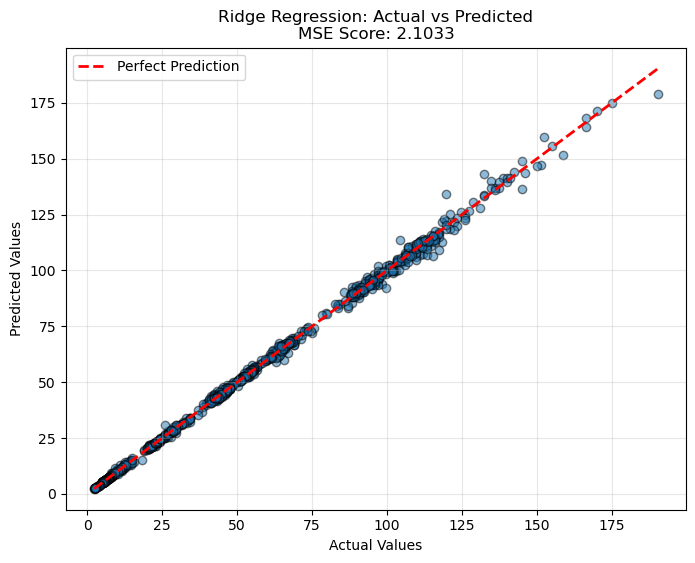

Best RMSE: 1.4503
Best Alpha: 1e-15


In [70]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have X and y from your data
# Get predictions from your best model
y_pred = ridge_regressor.predict(X)

# Create actual vs predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.5, edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Ridge Regression: Actual vs Predicted\nMSE Score: {-ridge_regressor.best_score_:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print metrics
print(f"Best RMSE: {np.sqrt(-ridge_regressor.best_score_):.4f}")
print(f"Best Alpha: {ridge_regressor.best_params_['alpha']}")

In [100]:
# Lasso for hyperparameter tuning
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
ls = Lasso(alpha=0.01, max_iter=10000)
parameters = {'alpha':[1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 5, 10, 15, 20, 30, 40, 50, 60]}
lasso_regressor = GridSearchCV(ls, parameters, scoring='neg_mean_squared_error', cv=5)
lasso_regressor.fit(X, y)
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

C:\Users\Maseru\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.553e+02, tolerance: 4.651e+01
  model = cd_fast.enet_coordinate_descent(
C:\Users\Maseru\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.081e+03, tolerance: 1.821e+02
  model = cd_fast.enet_coordinate_descent(
C:\Users\Maseru\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.165e+03, toler

{'alpha': 0.001}
-2.1019275196621403


In [92]:
from sklearn.metrics import r2_score
y_pred = lasso_regressor.predict(X_test)
lasso_r2 = r2_score(y_pred, y_test)
print(lasso_r2)

0.9988060356122439


In [96]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

MAE: 0.7007711511115322
RMSE: 1.2502340708415707
